In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit.circuit.library import Initialize
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
from scipy.special import rel_entr
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import random
import time

In [2]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_initial_circuit2, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit
from quantum_functions import add_crx_gates_and_measurements_to_circuit, get_probability_distribution, calculate_kl_divergence
from quantum_functions import score_circuit_kl_divergences, plot_measurement_histograms, create_cnot_pairs_from_locations, optimize_crx_angles
from quantum_functions import _process_target_state_input

In [35]:
def find_best_cnot_sequence_brute_force(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    max_cnot_depth: int = 1, # Limit the depth for practical reasons
    nshots: int = 1000
):
    """
    Performs a brute-force search to find the optimal sequence of CNOT gates
    between two quantum circuit "chunks" (circ1 and circ2) up to a specified depth.
    It evaluates all possible permutations of CNOTs and returns the sequence
    that yields the lowest combined KL divergence.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit (e.g., circ_bell).
        circ2 (QuantumCircuit): The second quantum circuit (e.g., circ_ghz_ish).
        state_vec_probs_target1 (list or np.array): The amplitudes of the target state vector
                                                     for the first classical register (c_measure1).
        state_vec_probs_target2 (list or np.array): The amplitudes of the target state vector
                                                     for the second classical register (c_measure2).
        max_cnot_depth (int): The maximum number of CNOT gates to include in a sequence.
                              Be cautious: computational cost grows exponentially with this value.
        nshots (int): The number of shots for the simulation. Defaults to 1000.

    Returns:
        tuple: A tuple containing (best_cnot_sequence, min_kl_sum).
               - best_cnot_sequence: A list of (global_control_idx, global_target_idx) tuples
                                     representing the optimal sequence of CNOTs found.
                                     An empty list if no CNOTs improve the baseline.
               - min_kl_sum: The minimum combined KL divergence found.
    """
    # Define a global tolerance for KL divergence stopping criteria
    KL_TOLERANCE = 0.00005

    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    num_total_qubits = ng_circ1 + ng_circ2

    print(f"\n--- Starting Brute-Force CNOT Sequence Optimization (Total Qubits: {num_total_qubits}, Max Depth: {max_cnot_depth}) ---")
    print(f"Number of qubits in chunk 1: {ng_circ1}")
    print(f"Number of qubits in chunk 2: {ng_circ2}")

    # 1. Evaluate baseline (no CNOTs)
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(
        base_combined_circuit, ng_circ1, []
    )
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(
        base_circuit_with_measurements,
        state_vec_probs_target1,
        state_vec_probs_target2,
        nshots
    )
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')

    min_kl_sum = initial_kl_sum
    best_cnot_sequence = [] # List of (global_control, global_target) tuples

    print(f"\nBaseline (No CNOTs) KL Sum: {initial_kl_sum:.6f}")
    print(f"Initial best KL sum: {min_kl_sum:.6f} (from baseline)")

    # Generate all possible single CNOTs between the two chunks (global indices)
    all_possible_single_cnots = []
    for control_q1_idx in range(ng_circ1):
        for target_q2_idx in range(ng_circ2):
            # CNOT from chunk1 to chunk2
            all_possible_single_cnots.append((control_q1_idx, ng_circ1 + target_q2_idx))
            # CNOT from chunk2 to chunk1
            all_possible_single_cnots.append((ng_circ1 + target_q2_idx, control_q1_idx))

    print(f"\n Number of possible single cnots {len(all_possible_single_cnots)}")
    # Brute-force search for the best sequence of CNOTs up to max_cnot_depth
    start_time = time.time()
    for num_cnots in range(1, max_cnot_depth + 1):
        print(f"\n--- Testing combinations with {num_cnots} CNOTs ---")
        # Use permutations to account for order, as CNOT order matters
        for cnot_combination in itertools.permutations(all_possible_single_cnots, num_cnots):
            temp_cnot_sequence = list(cnot_combination)

            # Create circuit with current CNOT sequence
            temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
            temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(
                temp_base_circuit, ng_circ1, temp_cnot_sequence
            )

            kl_div1, kl_div2 = score_circuit_kl_divergences(
                temp_circuit_with_cnots,
                state_vec_probs_target1,
                state_vec_probs_target2,
                nshots
            )

            if kl_div1 is not None and kl_div2 is not None:
                current_kl_sum = kl_div1 + kl_div2
                # print(f"  Testing CNOT sequence {temp_cnot_sequence}: KL Sum {current_kl_sum:.6f}") # For debugging brute force

                if current_kl_sum < min_kl_sum:
                    min_kl_sum = current_kl_sum
                    best_cnot_sequence = temp_cnot_sequence
                    print(f"  --> New best sequence found: {best_cnot_sequence} with KL Sum: {min_kl_sum:.6f}")
                
                # Check for early stopping criterion
                if min_kl_sum < KL_TOLERANCE:
                    print(f"  KL sum ({min_kl_sum:.6f}) below tolerance {KL_TOLERANCE}. Stopping early.")
                    search_complete_early = True
                    break # Exit inner loop

    end_time = time.time()
    print(f"Brute-Force CNOT search (max_depth={max_cnot_depth}) took: {end_time - start_time:.2f} seconds")
    
    # If no CNOT sequence improved over the baseline, return the baseline results
    if min_kl_sum >= initial_kl_sum:
        return [], initial_kl_sum
    else:
        return best_cnot_sequence, min_kl_sum

# ==============================================================================
# --- MAIN SEARCH ALGORITHMS (REFACTORED) ---
# ==============================================================================

def _run_single_greedy_search_from_start(
    circ1, circ2, state_vec_probs_target1, state_vec_probs_target2,
    all_possible_single_cnots, starting_cnot, min_cnot_depth, nshots,
):
    """
    [HELPER] Runs one greedy search path starting from a single CNOT.
    This version returns the best sequence found on this path, even if a later step is worse.
    """
    KL_TOLERANCE = 0.00005
    ng_circ1 = circ1.num_qubits
    best_cnot_sequence = [starting_cnot]
    
    initial_kl_for_path = score_circuit_kl_divergences(
        add_cnots_and_measurements_to_circuit(concatenate_circuits_with_separate_measurements(circ1, circ2), ng_circ1, best_cnot_sequence),
        state_vec_probs_target1, state_vec_probs_target2, nshots
    )
    if initial_kl_for_path is not None: initial_kl_for_path = initial_kl_for_path[0] + initial_kl_for_path[1]
    else: initial_kl_for_path = float('inf')

    best_sequence_on_path = list(best_cnot_sequence)
    best_kl_on_path = initial_kl_for_path
    current_kl_sum_on_path = initial_kl_for_path

    iteration_count = 1
    while True:
        iteration_count += 1
        improvement_made = False
        current_iteration_best_cnot = None
        current_iteration_min_kl_sum = current_kl_sum_on_path
        absolute_best_cnot_this_iter = None
        absolute_min_kl_sum_this_iter = float('inf')
        
        for candidate_cnot in all_possible_single_cnots:
            if candidate_cnot not in best_cnot_sequence:
                temp_cnot_sequence = best_cnot_sequence + [candidate_cnot]
                temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
                temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(temp_base_circuit, ng_circ1, temp_cnot_sequence)
                kl_div1, kl_div2 = score_circuit_kl_divergences(temp_circuit_with_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
                
                if kl_div1 is not None and kl_div2 is not None:
                    current_kl_sum = kl_div1 + kl_div2
                    
                    if current_kl_sum < current_iteration_min_kl_sum:
                        current_iteration_min_kl_sum = current_kl_sum
                        current_iteration_best_cnot = candidate_cnot
                        improvement_made = True
                    
                    if current_kl_sum < absolute_min_kl_sum_this_iter:
                        absolute_min_kl_sum_this_iter = current_kl_sum
                        absolute_best_cnot_this_iter = candidate_cnot
        
        if improvement_made:
            best_cnot_sequence.append(current_iteration_best_cnot)
            current_kl_sum_on_path = current_iteration_min_kl_sum
        else:
            if len(best_cnot_sequence) < min_cnot_depth and absolute_best_cnot_this_iter is not None:
                best_cnot_sequence.append(absolute_best_cnot_this_iter)
                current_kl_sum_on_path = absolute_min_kl_sum_this_iter
            else:
                break

        if current_kl_sum_on_path < best_kl_on_path:
            best_kl_on_path = current_kl_sum_on_path
            best_sequence_on_path = list(best_cnot_sequence)
            print(f"    --> Found a better KL on this path: {best_kl_on_path:.6f} at depth {len(best_sequence_on_path)}")

        if current_kl_sum_on_path < KL_TOLERANCE:
            print(f"  KL Sum ({current_kl_sum_on_path:.6f}) below tolerance. Early stopping this epoch.")
            break
            
    return best_sequence_on_path, best_kl_on_path

def _run_greedy_removal_search(
    circ1, circ2, state_vec_probs_target1, state_vec_probs_target2,
    initial_cnot_sequence, min_kl_sum_initial, min_cnot_depth, nshots
):
    """
    [NEW HELPER] Runs a greedy search by removing CNOTs from an initial sequence.
    """
    KL_TOLERANCE = 0.00005
    ng_circ1 = circ1.num_qubits
    best_cnot_sequence = list(initial_cnot_sequence)
    
    best_sequence_on_path = list(initial_cnot_sequence)
    best_kl_on_path = min_kl_sum_initial
    current_kl_sum_on_path = min_kl_sum_initial

    print(f"  Starting removal search with {len(initial_cnot_sequence)} CNOTs (KL Sum: {best_kl_on_path:.6f})")

    while len(best_cnot_sequence) > min_cnot_depth:
        improvement_made = False
        best_cnot_to_remove = None
        best_kl_after_removal = current_kl_sum_on_path
        
        for cnot_to_remove in best_cnot_sequence:
            temp_cnot_sequence = [c for c in best_cnot_sequence if c != cnot_to_remove]
            temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
            temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(temp_base_circuit, ng_circ1, temp_cnot_sequence)
            kl_div1, kl_div2 = score_circuit_kl_divergences(temp_circuit_with_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
            
            if kl_div1 is not None and kl_div2 is not None:
                current_kl_after_removal = kl_div1 + kl_div2
                if current_kl_after_removal < best_kl_after_removal:
                    best_kl_after_removal = current_kl_after_removal
                    best_cnot_to_remove = cnot_to_remove
                    improvement_made = True
        
        if improvement_made:
            best_cnot_sequence.remove(best_cnot_to_remove)
            current_kl_sum_on_path = best_kl_after_removal
            if current_kl_sum_on_path < best_kl_on_path:
                best_kl_on_path = current_kl_sum_on_path
                best_sequence_on_path = list(best_cnot_sequence)
                print(f"  Removed CNOT {best_cnot_to_remove}. New best KL Sum: {current_kl_sum_on_path:.6f} at depth {len(best_cnot_sequence)}")
        else:
            print("  No CNOT removal improved the score. Stopping removal search.")
            break
            
    return best_sequence_on_path, best_kl_on_path


def find_best_cnot_sequence_brute_force_on_list(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    cnot_list_to_test: list,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    max_cnot_depth: int,
    nshots: int
):
    """
    [NEW HELPER] Performs a brute-force search on a given list of CNOT candidates.
    """
    KL_TOLERANCE = 0.00005
    ng_circ1 = circ1.num_qubits
    
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(base_circuit_with_measurements, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')
    min_kl_sum = initial_kl_sum
    best_cnot_sequence = []
    
    print(f"\n--- Brute-force fallback: Testing permutations on {len(cnot_list_to_test)} candidates up to depth {max_cnot_depth} ---")
    start_time = time.time()
    for num_cnots in range(1, max_cnot_depth + 1):
        for cnot_combination in itertools.permutations(cnot_list_to_test, num_cnots):
            temp_cnot_sequence = list(cnot_combination)
            temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
            temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(temp_base_circuit, ng_circ1, temp_cnot_sequence)
            kl_div1, kl_div2 = score_circuit_kl_divergences(temp_circuit_with_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
            if kl_div1 is not None and kl_div2 is not None:
                current_kl_sum = kl_div1 + kl_div2
                if current_kl_sum < min_kl_sum:
                    min_kl_sum = current_kl_sum
                    best_cnot_sequence = temp_cnot_sequence
                    print(f"  --> New best sequence found: {best_cnot_sequence} with KL Sum: {min_kl_sum:.6f}")
                if min_kl_sum < KL_TOLERANCE:
                    print(f"  KL sum ({min_kl_sum:.6f}) below tolerance {KL_TOLERANCE}. Stopping early.")
                    return best_cnot_sequence, min_kl_sum
    
    end_time = time.time()
    print(f"Brute-Force CNOT search took: {end_time - start_time:.2f} seconds")
    
    if min_kl_sum >= initial_kl_sum: return [], initial_kl_sum
    else: return best_cnot_sequence, min_kl_sum

def find_best_cnot_sequence_multi_epoch(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    n_epochs: int = 10,
    min_cnot_depth: int = 1,
    nshots: int = 1000,
    threshold: float = 0.05
):
    """
    [NEW MAIN] Performs a multi-epoch greedy search with a brute-force fallback.
    """
    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits

    print(f"\n--- Starting Multi-Epoch Refined Search ---")
    start_total_time = time.time()
    
    state_list1_initial, _ = _process_target_state_input(state_probs_initial1)
    state_list2_initial, _ = _process_target_state_input(state_probs_initial2)
    state_list1_target, _ = _process_target_state_input(state_vec_probs_target1)
    state_list2_target, _ = _process_target_state_input(state_vec_probs_target2)

    combined_state_amplitudes0 = np.kron(state_list2_initial, state_list1_initial)
    sv0 = Statevector(combined_state_amplitudes0)
    combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)
    sv = Statevector(combined_state_amplitudes)
    density_matrix_sv0 = DensityMatrix(sv0)
    density_matrix_sv = DensityMatrix(sv)
    subtracted_density_matrix = density_matrix_sv - density_matrix_sv0
    matrix_to_plot = subtracted_density_matrix.data
    
    row_indices_sv, col_indices_sv = np.where(matrix_to_plot > threshold)
    row_indices_sv0, col_indices_sv0 = np.where(matrix_to_plot < -threshold)
    dim = matrix_to_plot.shape[0]
    labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)]
    row_labels_sv = [labels[i] for i in row_indices_sv]
    col_labels_sv = [labels[i] for i in col_indices_sv]
    all_labels_set = set(row_labels_sv) | set(col_labels_sv)
    sorted_labels = sorted(all_labels_set)
    row_labels_sv0 = [labels[i] for i in row_indices_sv0]
    col_labels_sv0 = [labels[i] for i in col_indices_sv0]
    all_labels_set0 = set(row_labels_sv0) | set(col_labels_sv0)
    sorted_labels0 = sorted(all_labels_set0)
    num_total_qubits_for_config = len(sorted_labels[0]) if sorted_labels else 0
    # All possible configurations from states mapped
    all_cnot_configurations = set()
    for ibit_string in sorted_labels0:
        for jbit_string in sorted_labels:
            locations_i_qiskit = [num_total_qubits_for_config - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
            locations_j_qiskit = [num_total_qubits_for_config - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
            new_cnot_pairs = create_cnot_pairs_from_locations(locations_i_qiskit, locations_j_qiskit)
            all_cnot_configurations.update(new_cnot_pairs)
    all_possible_single_cnots = sorted(list(all_cnot_configurations))
    
    print(f"Number of original CNOT candidates: {ng_circ1 * ng_circ2 * 2}")
    print(f"Number of refined CNOT candidates: {len(all_possible_single_cnots)}")

    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(base_circuit_with_measurements, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')

    best_overall_sequence = []
    best_overall_kl_sum = initial_kl_sum
    
    if not all_possible_single_cnots:
        print("\nNo CNOT candidates found. Skipping all searches.")
    else:
        # --- Multi-Epoch greedy search (addition) ---
        num_epochs_to_run = min(n_epochs, len(all_possible_single_cnots))
        shuffled_candidates = all_possible_single_cnots.copy()
        random.shuffle(shuffled_candidates)
        
        for epoch in range(num_epochs_to_run):
            starting_cnot = shuffled_candidates[epoch]
            temp_kl_sum = score_circuit_kl_divergences(add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [starting_cnot]), 
                                                       state_vec_probs_target1, state_vec_probs_target2, nshots)


            if temp_kl_sum is not None: 
                temp_kl_sum = temp_kl_sum[0] + temp_kl_sum[1]
                print(f"\n--- Starting Epoch {epoch + 1}/{num_epochs_to_run} (Addition) with CNOT: {starting_cnot} (KL: {temp_kl_sum:.6f}) ---")
            else:
                print(f"\n--- Starting Epoch {epoch + 1}/{num_epochs_to_run} ---")
                continue
            

            if temp_kl_sum >= initial_kl_sum: continue
            
            best_sequence_this_epoch, min_kl_this_epoch = _run_single_greedy_search_from_start(
                circ1, circ2, state_vec_probs_target1, state_vec_probs_target2,
                all_possible_single_cnots, starting_cnot, min_cnot_depth, nshots
            )
            
            print(f"  Epoch {epoch + 1} best KL Sum: {min_kl_this_epoch:.6f}")
            if min_kl_this_epoch < best_overall_kl_sum:
                best_overall_kl_sum = min_kl_this_epoch
                best_overall_sequence = best_sequence_this_epoch
                print(f"  --> Epoch {epoch + 1} found a new overall best KL Sum: {best_overall_kl_sum:.6f}")
        
        # --- Greedy CNOT removal search ---
        if best_overall_sequence:
            print("\n--- Starting Greedy CNOT Removal Search ---")
            best_sequence_after_removal, best_kl_after_removal = _run_greedy_removal_search(
                circ1, circ2, state_vec_probs_target1, state_vec_probs_target2,
                best_overall_sequence, best_overall_kl_sum, 0, nshots
            )
            if best_kl_after_removal < best_overall_kl_sum:
                best_overall_kl_sum = best_kl_after_removal
                best_overall_sequence = best_sequence_after_removal
                print(f"\n--> Removal search found a new overall best KL Sum: {best_overall_kl_sum:.6f}")

    # --- Brute-Force Fallback ---
    if best_overall_kl_sum >= initial_kl_sum:
        print(f"\nGreedy search failed to improve baseline KL sum ({best_overall_kl_sum:.6f}).")
        print("Initiating brute-force fallback on all candidate permutations.")
        brute_force_max_depth = min(4, len(all_possible_single_cnots))
        best_overall_sequence_bf, best_overall_kl_sum_bf = find_best_cnot_sequence_brute_force_on_list(
            circ1, circ2, all_possible_single_cnots, state_vec_probs_target1, state_vec_probs_target2,
            max_cnot_depth=brute_force_max_depth, nshots=nshots
        )
        if best_overall_kl_sum_bf < best_overall_kl_sum:
            best_overall_sequence = best_overall_sequence_bf
            best_overall_kl_sum = best_overall_kl_sum_bf
            print(f"\n--> Brute-force fallback found a better sequence with KL Sum: {best_overall_kl_sum:.6f}")
    
    end_total_time = time.time()
    print(f"\nTotal search took: {end_total_time - start_total_time:.2f} seconds.")
    
    return best_overall_sequence, best_overall_kl_sum


In [32]:
# 1. Define initial circuits for concatenation Dictionaries
state_probs_bell = {'00': 1/np.sqrt(2), '11': 1/np.sqrt(2)} # 2-qubit state
circ_bell = create_initial_circuit2(state_probs_bell)

state_probs_ghz_ish = {'01': 1/np.sqrt(2), '10': 1/np.sqrt(2)} # 2-qubit state
circ_ghz_ish = create_initial_circuit2(state_probs_ghz_ish)

# Define the target state vectors
state_probs_target1_amplitudes = {'01': 1/np.sqrt(2), '10': 1/np.sqrt(2)}
state_probs_target2_amplitudes = {'00': 1/np.sqrt(2), '11': 1/np.sqrt(2)}


In [33]:
# --- Demonstrate Brute-Force Search ---
print("\n" + "="*40)
print("--- Running Brute-Force Search ---")
print("="*40)
# WARNING: max_cnot_depth grows exponentially! Keep it small (e.g., 1, 2, or 3)
max_brute_force_depth = 10 # Testing up to 2 CNOTs for demonstration

best_cnot_sequence_brute_force, min_kl_brute_force = find_best_cnot_sequence_brute_force(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    max_cnot_depth=max_brute_force_depth,
    nshots=1000
)

print("\n" + "="*40)
if best_cnot_sequence_brute_force:
    print(f"Brute-Force Search Optimal CNOT sequence (Depth {max_brute_force_depth}) found:")
    for cnot in best_cnot_sequence_brute_force:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_brute_force:.6f}")

    # Construct and draw the final best circuit from brute-force search
    ng_circ1_for_brute_force = circ_bell.num_qubits
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, ng_circ1_for_brute_force, best_cnot_sequence_brute_force
    )
    print("\n--- Final Optimized Circuit (Brute-Force) ---")
    print(final_best_circuit_brute_force.draw('text'))
else:
    print("Brute-Force Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_brute_force:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_brute_force.draw('text'))
print("="*40 + "\n")


--- Running Brute-Force Search ---

--- Starting Brute-Force CNOT Sequence Optimization (Total Qubits: 4, Max Depth: 10) ---
Number of qubits in chunk 1: 2
Number of qubits in chunk 2: 2

Baseline (No CNOTs) KL Sum: 40.061120
Initial best KL sum: 40.061120 (from baseline)

 Number of possible single cnots 8

--- Testing combinations with 1 CNOTs ---
  --> New best sequence found: [(0, 2)] with KL Sum: 29.292002
  --> New best sequence found: [(2, 1)] with KL Sum: 29.213454

--- Testing combinations with 2 CNOTs ---
  --> New best sequence found: [(0, 2), (2, 0)] with KL Sum: 18.304097
  --> New best sequence found: [(0, 2), (2, 1)] with KL Sum: 17.750230
  --> New best sequence found: [(3, 1), (1, 3)] with KL Sum: 17.709808

--- Testing combinations with 3 CNOTs ---
  --> New best sequence found: [(2, 0), (0, 2), (3, 0)] with KL Sum: 9.503384
  --> New best sequence found: [(2, 0), (0, 2), (3, 1)] with KL Sum: 9.202481
  --> New best sequence found: [(2, 0), (3, 0), (1, 2)] with KL Su

In [ ]:
final_best_circuit_brute_force.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)

In [ ]:
plot_measurement_histograms(final_best_circuit_brute_force, nshots=2000, title_prefix="Greedy Optimized Circuit")

In [39]:
print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 20
min_greedy_depth = 10

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ_bell,
    circ_ghz_ish,
    state_probs_bell,
    state_probs_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold=0.05
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ_bell.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---
Number of original CNOT candidates: 8
Number of refined CNOT candidates: 12

--- Starting Epoch 1/12 (Addition) with CNOT: (1, 2) (KL: 29.220027) ---
    --> Found a better KL on this path: 18.448399 at depth 2
    --> Found a better KL on this path: 18.279945 at depth 3
    --> Found a better KL on this path: 9.174083 at depth 4
    --> Found a better KL on this path: 0.000001 at depth 5
  KL Sum (0.000001) below tolerance. Early stopping this epoch.
  Epoch 1 best KL Sum: 0.000001
  --> Epoch 1 found a new overall best KL Sum: 0.000001

--- Starting Epoch 2/12 (Addition) with CNOT: (1, 0) (KL: 29.969110) ---
    --> Found a better KL on this path: 19.216888 at depth 2
    --> Found a better KL on this path: 18.768495 at depth 3
    --> Found a better KL on this path: 9.226794 at depth 4
    --> Found a better KL on this path: 9.074324 at depth 5
    --> Found a better KL on this path: 0.000053 at

In [ ]:
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)

In [ ]:
plot_measurement_histograms(final_best_circuit_search, nshots=2000, title_prefix="Greedy Optimized Circuit")


--- Running CRX Angle Optimization (based on Brute-Force CNOT topology) ---

--- Starting CRX Angle Optimization (4 CRX gates) ---

Optimization Results:
  Success: True
  Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  Optimized Angles: ['3.1416', '3.1416', '3.1416', '3.1416']
CRX Angle Optimization took: 7.76 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['3.1416', '3.1416', '3.1416', '3.1416']
  Minimum Combined KL Divergence with Optimized CRX: 0.000139


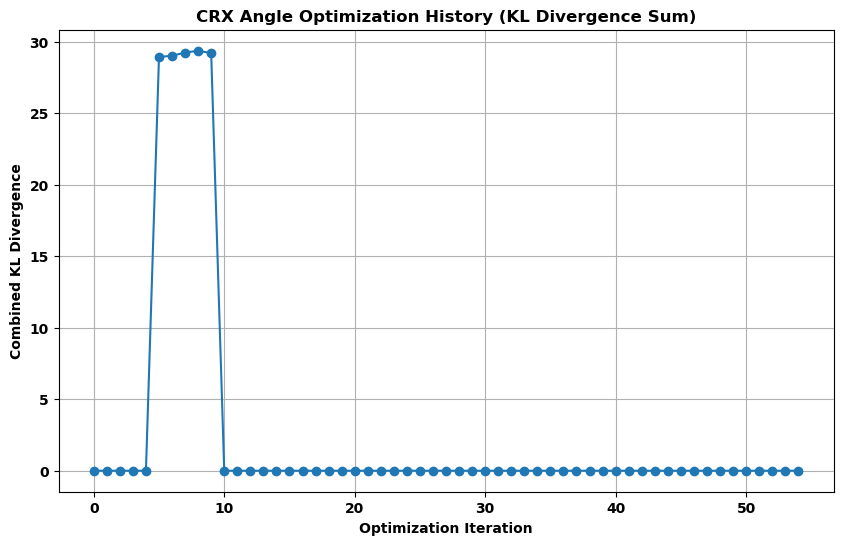


--- Final Optimized Circuit (CRX Angles) ---
              ┌──────────────────────────────────┐┌────────────┐┌────────────┐»
         q_0: ┤0                                 ├┤ Rx(3.1416) ├┤ Rx(3.1416) ├»
              │  Initialize(0.70711,0,0,0.70711) │└─────┬──────┘└─────┬──────┘»
         q_1: ┤1                                 ├──────┼─────────────┼───────»
              ├──────────────────────────────────┤      │             │       »
         q_2: ┤0                                 ├──────■─────────────┼───────»
              │  Initialize(0,0.70711,0.70711,0) │                    │       »
         q_3: ┤1                                 ├────────────────────■───────»
              └──────────────────────────────────┘                            »
c_measure1: 2/════════════════════════════════════════════════════════════════»
                                                                              »
c_measure2: 2/════════════════════════════════════════════════════════════

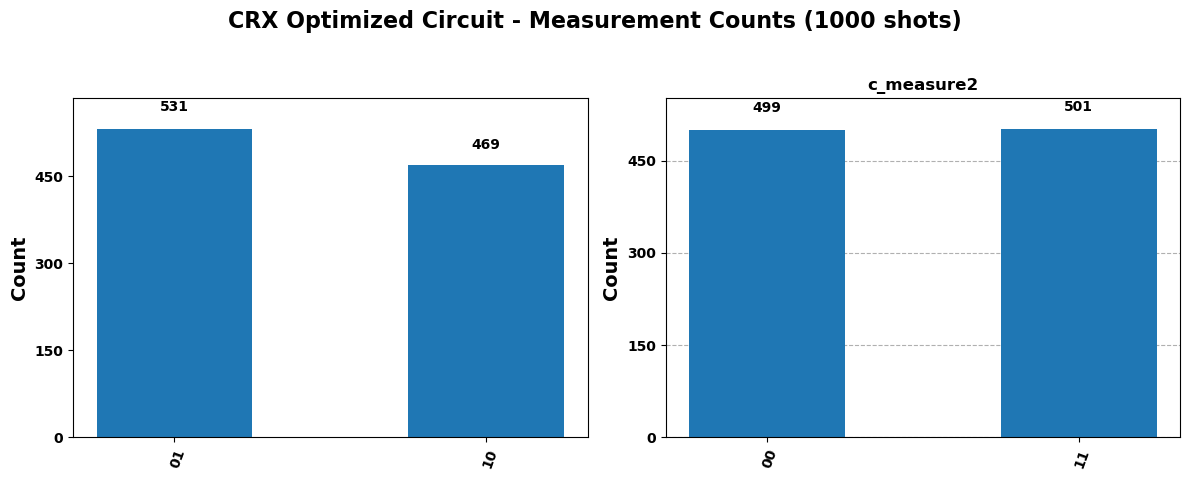

({'10': 469, '01': 531}, {'00': 499, '11': 501})

In [40]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on Brute-Force CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    best_cnot_sequence_brute_force, # Use the CNOT topology found by brute-force
    nshots=2000,
    etol=1e-4,
    opt_method='L-BFGS-B', # Using L-BFGS-B for angle optimization
    initial_angle_value=np.pi # Start angles at pi (CNOT equivalent)
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish),
    circ_bell.num_qubits,
    best_cnot_sequence_brute_force,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")

In [41]:
import numpy as np

# --- Function to normalize dictionary values ---
def vector_normalize_dictionary_values(input_dict):
    """Normalizes the values of a dictionary by dividing each value by the L2 norm of all values."""
    values = np.array(list(input_dict.values()), dtype=float)
    if values.size == 0:  # Handle empty dictionary
        return {}
    
    norm_val = np.linalg.norm(values)  # Calculate the L2 norm of the values

    if norm_val == 0:  # Avoid division by zero if all values are zero
        return {key: 0.0 for key in input_dict}

    normalized_dict = {}
    # Iterate through original dictionary items to maintain key order
    for i, (key, value) in enumerate(input_dict.items()):
        normalized_dict[key] = values[i] / norm_val
    return normalized_dict

In [ ]:
# This is a good set of functions!
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix

def _single_cnot_insertion_search(
    base_circuit: QuantumCircuit,
    ng_circ1: int,
    current_sequence: list,
    candidate_cnots: list,
    target_probs1: dict,
    target_probs2: dict,
    nshots: int,
    kl_tolerance: float
):
    """
    Finds the best single CNOT to insert into the current sequence at the best location.
    Returns the new sequence, its KL sum, and the added CNOT.
    """
    #print("   - Entering single CNOT insertion search -")
    best_single_cnot = None
    best_insertion_index = -1
    min_kl_after_add = float('inf')
    n_trials = 0
    
    remaining_cnots = [c for c in candidate_cnots if c not in current_sequence]
    if not remaining_cnots:
        print("   - No remaining CNOTs to add. Ending single-CNOT search.")
        return current_sequence, float('inf'), None

    for cnot_to_add in remaining_cnots:
        # Try inserting the CNOT at every possible position in the current sequence
        for i in range(len(current_sequence) + 1):
            n_trials += 1
            trial_sequence = current_sequence[:i] + [cnot_to_add] + current_sequence[i:]
            
            trial_circuit = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, trial_sequence)
            kl_divs = score_circuit_kl_divergences(trial_circuit, target_probs1, target_probs2, nshots)
            
            if kl_divs is not None:
                kl_sum = kl_divs[0] + kl_divs[1]
                if kl_sum < min_kl_after_add:
                    min_kl_after_add = kl_sum
                    best_single_cnot = cnot_to_add
                    best_insertion_index = i
                    
    
    if best_single_cnot is not None:
        new_sequence = current_sequence[:best_insertion_index] + [best_single_cnot] + current_sequence[best_insertion_index:]
        return new_sequence, min_kl_after_add, best_single_cnot
        print(f"  - No. CNOT tested insertion: {n_trials} | Best insertion KL sum: {min_kl_of_candidates:.6f}")
    else:
        print(f"  - No. CNOT tested insertion: {n_trials}")

    return current_sequence, float('inf'), None

def _pairwise_addition_search(
    base_circuit: 'QuantumCircuit',
    ng_circ1: int,
    initial_sequence: list,
    candidate_cnots: list,
    target_probs1: dict,
    target_probs2: dict,
    nshots: int,
    kl_tolerance: float = 0.00005,
    nperm: int = 2
):
    """
    Iteratively adds the best CNOT pair or single CNOT based on which provides
    the greater reduction in KL divergence.
    Returns the final sequence and its corresponding KL sum.
    """
    print("  - Starting CNOT search -")
    current_sequence = list(initial_sequence)
    
    # Calculate baseline KL with the initial sequence
    base_circuit_kl = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, current_sequence)
    kl_divs_base = score_circuit_kl_divergences(base_circuit_kl, target_probs1, target_probs2, nshots)
    best_kl_sum = kl_divs_base[0] + kl_divs_base[1] if kl_divs_base is not None else float('inf')
    
    improvement_made = True
    min_kl_of_candidates = best_kl_sum
    while improvement_made:
        improvement_made = False
        
        # Initialize best candidates for this iteration
        best_candidate_sequence = None
        
        
        remaining_cnots = [c for c in candidate_cnots if c not in current_sequence]
        shuffled_candidates = remaining_cnots.copy()
        random.shuffle(shuffled_candidates)

        # --- PHASE 1: Find the best PAIR to add ---
        if len(shuffled_candidates) >= nperm:
            best_pair_to_add = None
            min_kl_after_pair_add = float('inf')
            n_trials_pair = 0

            for pair in itertools.permutations(shuffled_candidates, nperm):
                n_trials_pair += 1
                trial_sequence = current_sequence + list(pair)
                trial_circuit = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, trial_sequence)
                kl_divs = score_circuit_kl_divergences(trial_circuit, target_probs1, target_probs2, nshots)
                
                if kl_divs is not None:
                    kl_sum = kl_divs[0] + kl_divs[1]
                    if kl_sum < min_kl_after_pair_add:
                        min_kl_after_pair_add = kl_sum
                        best_pair_to_add = list(pair)
            
            if best_pair_to_add is not None:
                min_kl_of_candidates = min_kl_after_pair_add
                best_candidate_sequence = current_sequence + best_pair_to_add
                print(f"  - No. tested pairs: {n_trials_pair} | Best pair KL sum: {min_kl_of_candidates:.6f}")
            else: 
                print(f"  - No. tested pairs: {n_trials_pair}")


        # --- PHASE 2: Find the best SINGLE CNOT to add ---
        new_sequence_single, new_kl_sum_single, added_cnot = _single_cnot_insertion_search(
            base_circuit, ng_circ1, current_sequence, candidate_cnots,
            target_probs1, target_probs2, nshots, kl_tolerance
        )
        
        if added_cnot is not None:
            if new_kl_sum_single < min_kl_of_candidates:
                min_kl_of_candidates = new_kl_sum_single
                best_candidate_sequence = new_sequence_single
                print(f"  - Best single CNOT insertion KL Sum: {min_kl_of_candidates:.6f}")
            else:
                print("  - Single CNOT insertion did not improve upon the best pair.")


        # --- PHASE 3: Update the sequence if a better candidate was found ---
        if best_candidate_sequence is not None and min_kl_of_candidates < best_kl_sum - kl_tolerance:
            current_sequence = best_candidate_sequence
            best_kl_sum = min_kl_of_candidates
            improvement_made = True
            print(f"  - Adopted new sequence. New KL Sum: {best_kl_sum:.6f}")
        else:
            print("  - No significant improvement found from pairs or single CNOTs. Ending search.")
            break
                
    return current_sequence, best_kl_sum

def find_best_cnot_sequence_iterative_pairwise2(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    nshots: int = 1000,
    threshold: float = 0.05,
    nperm: int = 2
):
    """
    Performs an iterative optimization loop by separating pairwise addition
    and removal phases.
    """
    import time
    
    ng_circ1 = circ1.num_qubits
    KL_TOLERANCE = 0.00005

    print(f"\n--- Starting Iterative Pairwise Search ---")
    start_total_time = time.time()

    # --- Step 1: Build refined CNOT candidate list ---
    state_list1_initial, _ = _process_target_state_input(state_probs_initial1)
    state_list2_initial, _ = _process_target_state_input(state_probs_initial2)
    state_list1_target, _ = _process_target_state_input(state_vec_probs_target1)
    state_list2_target, _ = _process_target_state_input(state_vec_probs_target2)

    combined_state_amplitudes0 = np.kron(state_list2_initial, state_list1_initial)
    combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)
    sv0 = Statevector(combined_state_amplitudes0)
    sv = Statevector(combined_state_amplitudes)
    dm0 = DensityMatrix(sv0)
    dm = DensityMatrix(sv)
    diff = dm - dm0
    matrix_data = diff.data

    row_indices, col_indices = np.where(matrix_data > threshold)
    row_indices0, col_indices0 = np.where(matrix_data < -threshold)

    dim = matrix_data.shape[0]
    labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)]
    active_labels = set(labels[i] for i in row_indices) | set(labels[i] for i in col_indices)
    active_labels0 = set(labels[i] for i in row_indices0) | set(labels[i] for i in col_indices0)

    all_cnot_configurations = set()
    for ibit_string in active_labels0:
        for jbit_string in active_labels:
            i_locs = [len(ibit_string) - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
            j_locs = [len(jbit_string) - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
            all_cnot_configurations.update(create_cnot_pairs_from_locations(i_locs, j_locs))
    initial_cnot_config = sorted(list(all_cnot_configurations))

    print(f"Number of initial CNOT candidates: {len(initial_cnot_config)}")
    
    # Optional: Plotting Real and Imaginary parts separately (also without annotations)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    sns.heatmap(np.real(matrix_data),
                annot=False,
                cmap="RdBu",
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                ax=axes[0])
    axes[0].set_title("Real Part of Subtracted Density Matrix")
    axes[0].set_xlabel("Column Index (Binary State)")
    axes[0].set_ylabel("Row Index (Binary State)")

    sns.heatmap(np.imag(matrix_data),
                annot=False,
                cmap="coolwarm",
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                ax=axes[1])
    axes[1].set_title("Imaginary Part of Subtracted Density Matrix")
    axes[1].set_xlabel("Column Index (Binary State)")
    axes[1].set_ylabel("Row Index (Binary State)")

    plt.tight_layout()
    plt.savefig('dens_state_diff.svg')
    plt.close(fig)

    # --- Step 2: Baseline (no CNOTs) ---
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_divs = score_circuit_kl_divergences(base_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_divs[0] + kl_divs[1] if kl_divs is not None else float('inf')

    print(f"Initial KL-divergence: {initial_kl_sum:.6f}")

    if len(initial_cnot_config) < 2:
        print("Not enough CNOT candidates to form a pair. Skipping search.")
        return initial_cnot_config, [], [], initial_kl_sum

    # --- Step 3: Pairwise Addition Phase ---
    best_add_sequence, best_add_kl_sum = _pairwise_addition_search(
        base_combined_circuit, ng_circ1, [], initial_cnot_config,
        state_vec_probs_target1, state_vec_probs_target2, nshots, KL_TOLERANCE, nperm
    )
    print(f"\n--- Pairwise Addition Result ---")
    print(f"Best sequence after addition: {best_add_sequence}")
    print(f"KL sum after addition: {best_add_kl_sum:.6f}")

    end_time = time.time()
    print(f"\nTotal search time: {end_time - start_total_time:.2f} seconds.")

    # Return the configurations as requested
    return (
        initial_cnot_config,
        best_add_sequence,
        best_add_kl_sum
    )


--- Running iterative pair-wise Search ---

--- Starting Iterative Pairwise Search ---
Number of initial CNOT candidates: 12
Initial KL-divergence: 40.060761
  - Starting CNOT search -
  - No. tested pairs: 1320 | Best pair KL sum: 9.146051
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 9.146051
  - No. tested pairs: 504 | Best pair KL sum: 0.000034
  - Best single CNOT insertion KL Sum: 0.000023
  - Adopted new sequence. New KL Sum: 0.000023
  - No. tested pairs: 336 | Best pair KL sum: 8.958087
  - Single CNOT insertion did not improve upon the best pair.
  - No significant improvement found from pairs or single CNOTs. Ending search.

--- Pairwise Addition Result ---
Best sequence after addition: [(2, 1), (3, 1), (0, 2), (1, 3)]
KL sum after addition: 0.000023

Total search time: 375.17 seconds.

Iterative Search Optimal CNOT sequence found after addition phase:
  q[2] -> q[1]
  q[3] -> q[1]
  q[0] -> q[2]
  q[1] -> q[3]
With mini

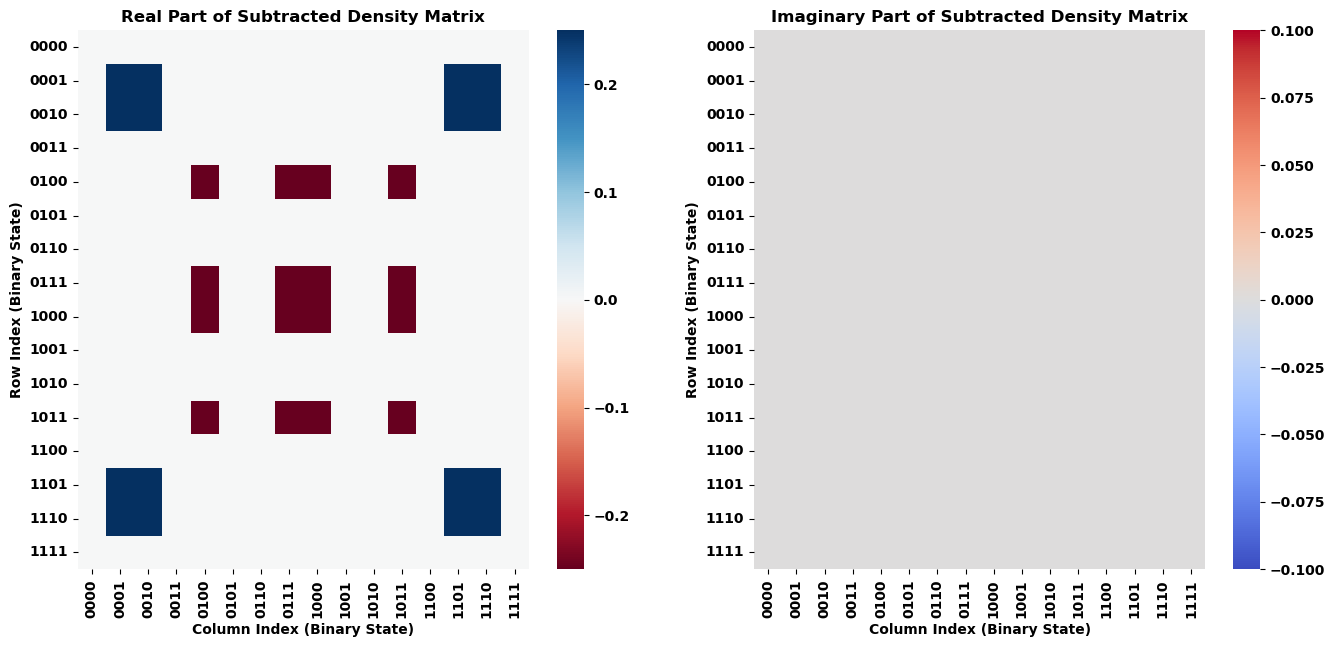

In [50]:
# This is a good set of functions!
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix

# This is the call:
# --- Demonstrate Iterative Pairwise Search ---
print("\n" + "="*40)
print("--- Running iterative pair-wise Search ---")
print("="*40)

# Apply vector normalization to the new dictionaries
normalized_state_target1_amplitudes = vector_normalize_dictionary_values(state_probs_target1_amplitudes)
normalized_state_target2_amplitudes = vector_normalize_dictionary_values(state_probs_target2_amplitudes)
normalized_state_bell = vector_normalize_dictionary_values(state_probs_bell)
normalized_state_ghz_ish = vector_normalize_dictionary_values(state_probs_ghz_ish)


initial_cnot_config, best_add_sequence, best_add_kl_sum = find_best_cnot_sequence_iterative_pairwise2(
    circ_bell,
    circ_ghz_ish,
    normalized_state_bell, 
    normalized_state_ghz_ish,
    normalized_state_target1_amplitudes,
    normalized_state_target2_amplitudes,
    nshots=5000,
    threshold=0.01,
    nperm=3
)

print("\n" + "="*40)
if best_add_sequence: # Use best_add_sequence as it's the result of the addition phase
    print("Iterative Search Optimal CNOT sequence found after addition phase:")
    for cnot in best_add_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {best_add_kl_sum:.6f}")

    # Construct and draw the final best circuit from the search
    ng_circ1_for_search = circ_bell.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_add_sequence
    )
    print("\n--- Final Optimized Circuit (Iterative Pairwise Search) ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Iterative Pairwise Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {best_add_kl_sum:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


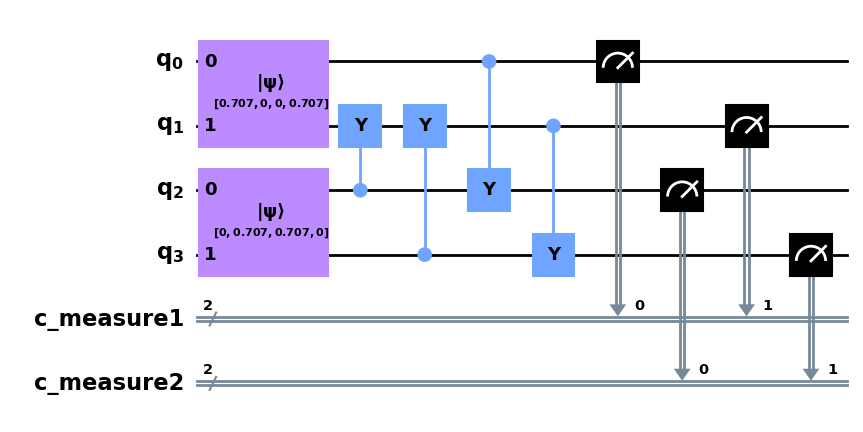

In [51]:
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'10': 1012, '01': 988}
Counts for c_measure2: {'11': 996, '00': 1004}


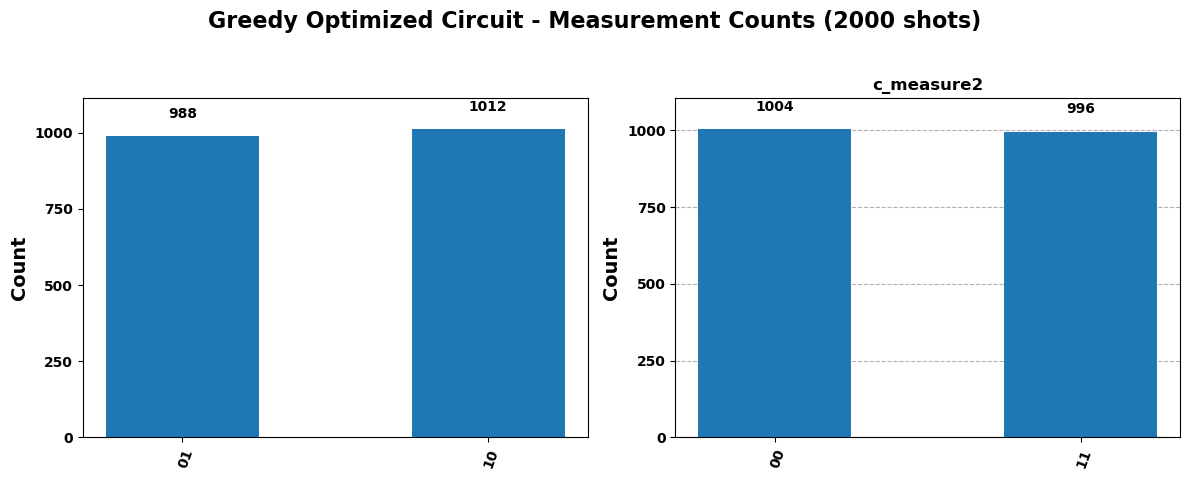

({'10': 1012, '01': 988}, {'11': 996, '00': 1004})

In [52]:
plot_measurement_histograms(final_best_circuit_search, nshots=2000, title_prefix="Greedy Optimized Circuit")

In [53]:
# --- New Dictionary Definitions ---
# State Set 5a: A simple distribution where states with more '1's have higher values.
state_set_5a_dict = {
    '000': 1,
    '001': 2,
    '010': 2,
    '100': 2,
    '011': 4,
    '101': 4,
    '110': 4,
    '111': 8
}

# State Set 6a: A bell state-like distribution where certain states are highly probable.
# This simulates an entangled state before interaction.
state_set_6a_dict = {
    '0000': 5,
    '0001': 1,
    '0010': 1,
    '0011': 1,
    '0100': 1,
    '0101': 1,
    '0110': 1,
    '0111': 1,
    '1000': 1,
    '1001': 1,
    '1010': 1,
    '1011': 1,
    '1100': 1,
    '1101': 1,
    '1110': 1,
    '1111': 5
}

# Interacted State Set 5a: Simulating a CNOT interaction between qubits 1 and 2
# We increase the probability of entangled states like '011' and '110'.
interacted_state_set_5a_dict = {
    '000': 1,
    '001': 1,
    '010': 1,
    '100': 1,
    '011': 6,
    '101': 2,
    '110': 6,
    '111': 2
}

# Interacted State Set 6a: The bell state distribution is now more focused on states
# that would result from an interaction, such as '0000' and '1111' becoming highly probable.
interacted_state_set_6a_dict = {
    '0000': 8,
    '0001': 1,
    '0010': 1,
    '0011': 1,
    '0100': 1,
    '0101': 1,
    '0110': 1,
    '0111': 1,
    '1000': 1,
    '1001': 1,
    '1010': 1,
    '1011': 1,
    '1100': 1,
    '1101': 1,
    '1110': 1,
    '1111': 8
}

# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set 5a:", state_set_5a_dict)
print("State Set 6a:", state_set_6a_dict)
print("Interacted State Set 5a:", interacted_state_set_5a_dict)
print("Interacted State Set 6a:", interacted_state_set_6a_dict)

# Apply vector normalization to the new dictionaries
normalized_state_set_5a_dict_vec = vector_normalize_dictionary_values(state_set_5a_dict)
normalized_state_set_6a_dict_vec = vector_normalize_dictionary_values(state_set_6a_dict)
normalized_interacted_state_set_5a_dict_vec = vector_normalize_dictionary_values(interacted_state_set_5a_dict)
normalized_interacted_state_set_6a_dict_vec = vector_normalize_dictionary_values(interacted_state_set_6a_dict)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_state_set_5a_dict_vec)
print("Normalized State Set 6a (Vector Norm):", normalized_state_set_6a_dict_vec)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_interacted_state_set_5a_dict_vec)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_interacted_state_set_6a_dict_vec)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_state_set_5a_dict_vec)
circ2 = create_initial_circuit2(normalized_state_set_6a_dict_vec)

--- New Dictionary Definitions ---
State Set 5a: {'000': 1, '001': 2, '010': 2, '100': 2, '011': 4, '101': 4, '110': 4, '111': 8}
State Set 6a: {'0000': 5, '0001': 1, '0010': 1, '0011': 1, '0100': 1, '0101': 1, '0110': 1, '0111': 1, '1000': 1, '1001': 1, '1010': 1, '1011': 1, '1100': 1, '1101': 1, '1110': 1, '1111': 5}
Interacted State Set 5a: {'000': 1, '001': 1, '010': 1, '100': 1, '011': 6, '101': 2, '110': 6, '111': 2}
Interacted State Set 6a: {'0000': 8, '0001': 1, '0010': 1, '0011': 1, '0100': 1, '0101': 1, '0110': 1, '0111': 1, '1000': 1, '1001': 1, '1010': 1, '1011': 1, '1100': 1, '1101': 1, '1110': 1, '1111': 8}

--- Vector Normalized Dictionary Definitions ---
Normalized State Set 5a (Vector Norm): {'000': 0.08944271909999159, '001': 0.17888543819998318, '010': 0.17888543819998318, '100': 0.17888543819998318, '011': 0.35777087639996635, '101': 0.35777087639996635, '110': 0.35777087639996635, '111': 0.7155417527999327}
Normalized State Set 6a (Vector Norm): {'0000': 0.625, '00


--- Running Multi-Epoch Refined Search ---

--- Starting Iterative Pairwise Search ---
Number of initial CNOT candidates: 42
Initial KL-divergence: 1.165619
  - Starting CNOT search -
  - No. tested pairs: 1722 | Best pair KL sum: 0.357305
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.357305
  - No. tested pairs: 1560 | Best pair KL sum: 0.340087
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.340087
  - No. tested pairs: 1406 | Best pair KL sum: 0.333115
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.333115
  - No. tested pairs: 1260 | Best pair KL sum: 0.338932
  - Best single CNOT insertion KL Sum: 0.334160
  - No significant improvement found from pairs or single CNOTs. Ending search.

--- Pairwise Addition Result ---
Best sequence after addition: [(5, 2), (2, 0), (5, 4), (6, 4), (4, 3), (6, 3)]
KL sum after addition: 

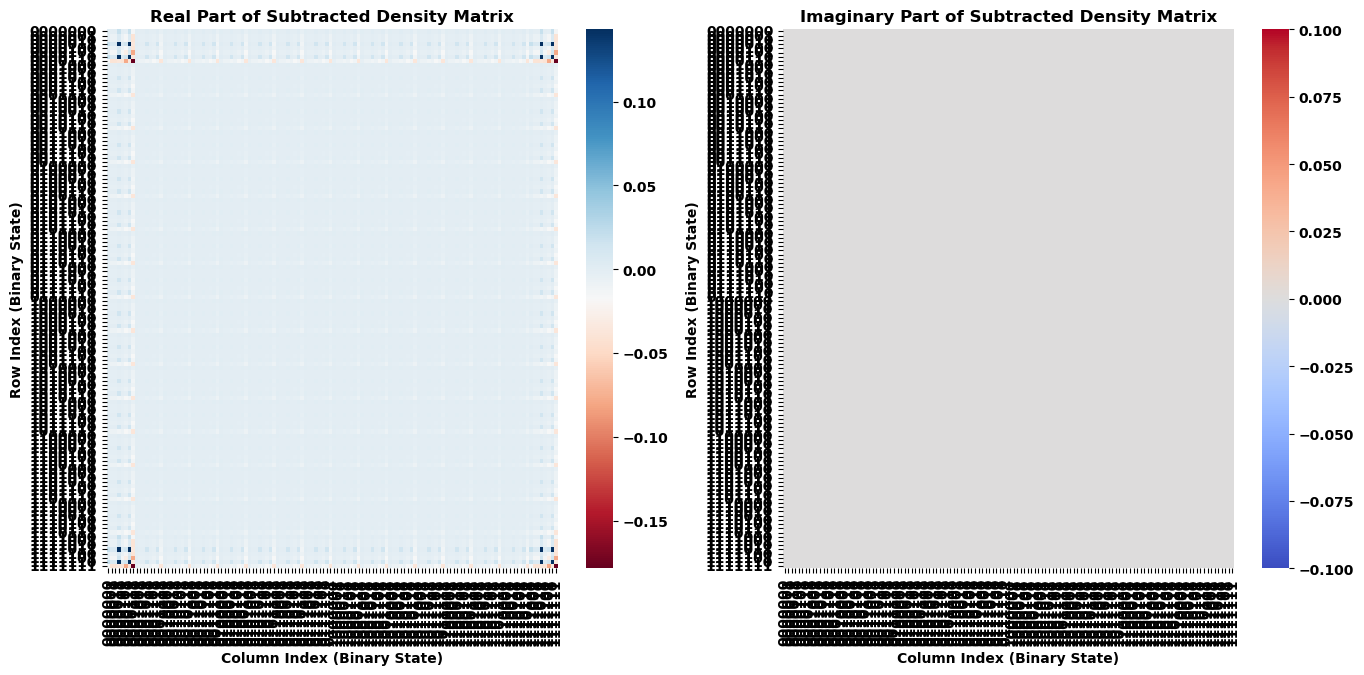

In [56]:
print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

initial_cnot_config, best_cnot_sequence, min_kl_sum  = find_best_cnot_sequence_iterative_pairwise2(
    circ1,
    circ2,
    normalized_state_set_5a_dict_vec,
    normalized_state_set_6a_dict_vec,
    normalized_interacted_state_set_5a_dict_vec,
    normalized_interacted_state_set_6a_dict_vec,
    nshots=5000,
    threshold=0.01,
    nperm=2
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (6 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['3.1253', '3.1416', '3.1400', '3.0874', '3.1416', '2.8982']
CRX Angle Optimization took: 18.78 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['3.1253', '3.1416', '3.1400', '3.0874', '3.1416', '2.8982']
  Minimum Combined KL Divergence with Optimized CRX: 0.378544


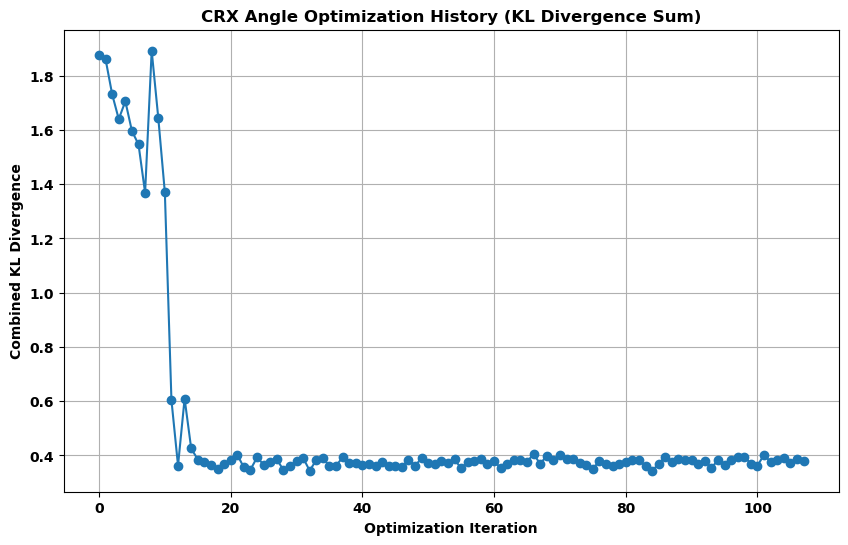


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 3/»
              »
c_measure2: 4/»
              »
«                             ┌───────────────────────────────────────────────────────────────────────────────┐                »
«         q_0: ───────────────┤0                                                                              ├────────────────»
«                             │                                                                               │                »
«         q_1: ───────────────┤1 Initialize(0.089443,0.17889,0.17889,0.35777,0.17889,0.35777,0.35777,0.71554) ├────────────────»
«                             │                                                                               │                »
«    

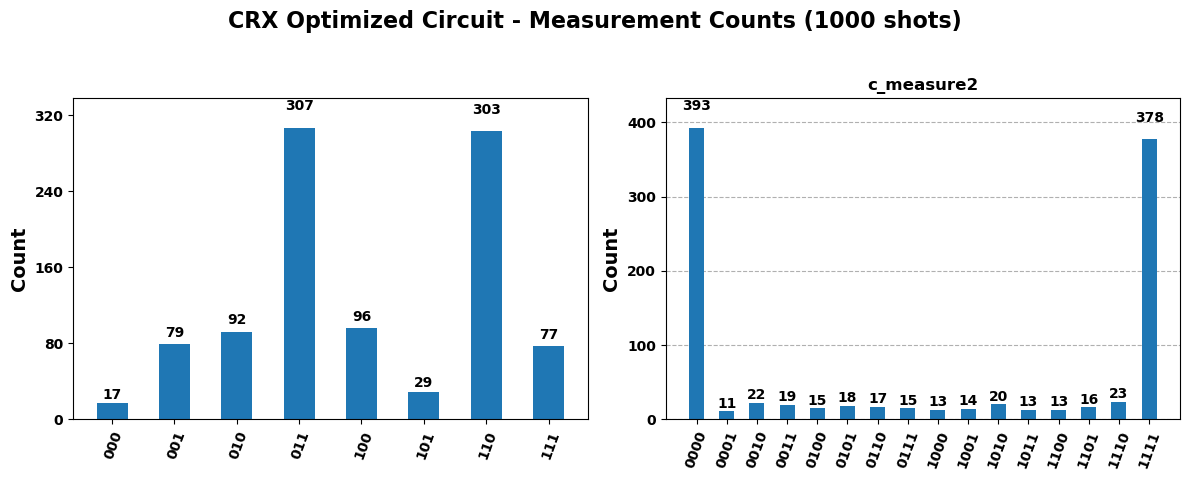

({'011': 307,
  '110': 303,
  '001': 79,
  '010': 92,
  '111': 77,
  '100': 96,
  '101': 29,
  '000': 17},
 {'0100': 15,
  '1111': 378,
  '0000': 393,
  '1010': 20,
  '1001': 14,
  '0011': 19,
  '1110': 23,
  '0101': 18,
  '0001': 11,
  '0111': 15,
  '1101': 16,
  '0110': 17,
  '0010': 22,
  '1011': 13,
  '1000': 13,
  '1100': 13})

In [57]:
# --- Optimize CRX angles for the pair-wise CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_interacted_state_set_5a_dict_vec,
    normalized_interacted_state_set_6a_dict_vec,
    best_cnot_sequence, # Use the CNOT topology found by pair-wise
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")

In [ ]:
print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 50
min_greedy_depth = 40

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_state_set_5a_dict_vec,
    normalized_state_set_6a_dict_vec,
    normalized_interacted_state_set_5a_dict_vec,
    normalized_interacted_state_set_6a_dict_vec,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=1000,
    threshold=0.05
)


print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---
Number of original CNOT candidates: 24
Number of refined CNOT candidates: 42

--- Starting Epoch 1/42 (Addition) with CNOT: (1, 3) (KL: 3.200203) ---

--- Starting Epoch 2/42 (Addition) with CNOT: (3, 4) (KL: 2.899801) ---

--- Starting Epoch 3/42 (Addition) with CNOT: (6, 3) (KL: 2.665086) ---

--- Starting Epoch 4/42 (Addition) with CNOT: (5, 4) (KL: 2.708009) ---

--- Starting Epoch 5/42 (Addition) with CNOT: (3, 1) (KL: 1.330051) ---

--- Starting Epoch 6/42 (Addition) with CNOT: (5, 3) (KL: 2.955133) ---

--- Starting Epoch 7/42 (Addition) with CNOT: (1, 4) (KL: 3.529385) ---

--- Starting Epoch 8/42 (Addition) with CNOT: (3, 6) (KL: 2.844013) ---

--- Starting Epoch 9/42 (Addition) with CNOT: (4, 5) (KL: 2.684488) ---

--- Starting Epoch 10/42 (Addition) with CNOT: (1, 5) (KL: 3.333776) ---

--- Starting Epoch 11/42 (Addition) with CNOT: (3, 2) (KL: 0.826185) ---
    --> Found a better KL on 